In [ ]:
from pathlib import Path
import json as _json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = MAX_EPOCHS
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
N_RUNS_TSCV = 4
TSCV_EPOCHS = 100
SYMLOG_CAP = float(np.log1p(3.0))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing

In [ ]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window_data_raw = window[feature_cols].to_numpy(dtype=np.float32)
            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols_row = ["MC_MIB", "MC_MID", "MC_SMALL",
                               "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                               "Leverage", "Cash_Ratio", "Size_SL",
                               "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols_row].iloc[-1].to_numpy(dtype=np.float32)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "window_data_raw": window_data_raw,
                "static_data": static_data,
                "sector": sector_str,
                "window_dates": window["Date"].to_numpy(),
                "window_days": (window["Date"] - window["Date"].iloc[0]).dt.days.to_numpy(),
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "window_data_raw": seq["window_data_raw"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
                "window_dates": seq["window_dates"],
                "window_days": seq["window_days"],
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse per-target rows into one row per (company, year) with a 3-dim label vector."""
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        window_dates = group.iloc[0]["window_dates"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "window_data_raw": group.iloc[0].get("window_data_raw", window_data),
            "window_dates": window_dates,
            "sector": group.iloc[0]["sector"] if "sector" in group.iloc[0].index else "",
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

## Pipeline Setup

In [ ]:
DAILY_FEATURES = [  # 21 features, 365 timesteps
    'Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield',
    'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume',
    'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close',
    'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom',
    'TTF_Gas_Close', 'NFCI',
]
MONTHLY_FEATURES = [  # 5 features, 12 timesteps
    'Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM',
]
QUARTERLY_FEATURES = ['IT_GDP']  # 1 feature, 4 timesteps

SELECTED_FEATURES = DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
daily_indices = [feature_cols.index(f) for f in DAILY_FEATURES]
monthly_indices = [feature_cols.index(f) for f in MONTHLY_FEATURES]
quarterly_indices = [feature_cols.index(f) for f in QUARTERLY_FEATURES]

print(f"Daily features ({len(DAILY_FEATURES)}): {DAILY_FEATURES}")
print(f"Monthly features ({len(MONTHLY_FEATURES)}): {MONTHLY_FEATURES}")
print(f"Quarterly features ({len(QUARTERLY_FEATURES)}): {QUARTERLY_FEATURES}")
print(f"Total SELECTED_FEATURES: {len(SELECTED_FEATURES)}")

# Symlog transformation
idx_value = data_df["target"].isin(PREDICTION_TARGETS)
y_val = data_df.loc[idx_value, "label_value"]
data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

train_data, val_data, test_data = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

Daily features (21): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom', 'TTF_Gas_Close', 'NFCI']
Monthly features (5): ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
Quarterly features (1): ['IT_GDP']
Total SELECTED_FEATURES: 27
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (1028 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (5174), val = 2023 (513)


In [ ]:
WINSOR_CAP = 3.0
SECTOR_LIST = sorted(data_df["sector"].unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)
    sector_oh = sector_onehot(sector_str)
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
data_df_imp_base = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
data_df_imp_base["static_data"] = data_df_imp_base.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)

n_drop_missing = len(data_df) - len(data_df_imp_base)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; "
      f"{len(data_df_imp_base)} remaining.")

data_df_imp = data_df_imp_base.copy()

sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(raw_ratio)} "
      f"({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 3 + N_SECTORS + 9
NEW_STATIC_SLICE = slice(3 + N_SECTORS, 3 + N_SECTORS + 9)
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

train_data_imp, val_data_imp, test_data_imp = split_to_single(data_df_imp, test_year_cutoff=TEST_YEAR_CUTOFF)
mtl_train_imp_raw = extract_mtl_df(train_data_imp)
mtl_val_imp_raw   = extract_mtl_df(val_data_imp)
mtl_test_imp      = extract_mtl_df(test_data_imp)

def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 970 samples missing prior-year fundamentals; 5745 remaining.
Robust symlog label: capped 493/5745 (8.58%) at +/-3.
STATIC_DIM_IMP=22 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:22 (only prior gets RobustScaler)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4367), val = 2023 (459)


## Frequency Verification

In [ ]:
def verify_feature_frequency(data_df, feature_cols_list, label):
    """For each feature, compute median obs count per (company, year)."""
    rows = []
    for feat in feature_cols_list:
        if feat not in feature_cols:
            continue
        idx = feature_cols.index(feat)
        counts = []
        sample = data_df.drop_duplicates(subset=["company", "year"]).head(30)
        for _, r in sample.iterrows():
            arr = r["window_data"]
            col = arr[:, idx]
            counts.append(int(np.sum(~np.isnan(col))))
        if counts:
            rows.append({
                "feature": feat,
                "median_n_obs": int(np.median(counts)),
                "min_n_obs": int(np.min(counts)),
                "max_n_obs": int(np.max(counts)),
            })
    return pd.DataFrame(rows)

print("Daily features - median obs per (company, year):")
display(verify_feature_frequency(data_df_imp, DAILY_FEATURES, "daily"))
print("\nMonthly features - median obs per (company, year):")
display(verify_feature_frequency(data_df_imp, MONTHLY_FEATURES, "monthly"))
print("\nQuarterly features - median obs per (company, year):")
display(verify_feature_frequency(data_df_imp, QUARTERLY_FEATURES, "quarterly"))
print("\nExpected: daily ~250, monthly ~12, quarterly ~4.")

Daily features - median obs per (company, year):


,feature,median_n_obs,min_n_obs,max_n_obs
0,Close_logret,255,252,256
1,Volume_log,255,252,256
2,DE10YT_Yield,255,252,256
3,IT10YT_Yield,255,252,256
4,EURUSD_Close,255,252,256
5,EURUSD_Volume,255,252,256
6,FTMIB_Close,255,252,256
7,FTMIB_Volume,255,252,256
8,GVZ_Close,255,252,256
9,Brent_Close,255,252,256



Monthly features - median obs per (company, year):


,feature,median_n_obs,min_n_obs,max_n_obs
0,Euribor_3M,255,252,256
1,IT_Inflation,255,252,256
2,IT_Unemployment,255,252,256
3,PCOPPUSDM,255,252,256
4,PALUMUSDM,255,252,256



Quarterly features - median obs per (company, year):


,feature,median_n_obs,min_n_obs,max_n_obs
0,IT_GDP,255,252,256



Expected: daily ~250, monthly ~12, quarterly ~4.


## Multi-Frequency Aggregation

In [ ]:
def build_multifreq_tensors(row, daily_idx, monthly_idx, quarterly_idx, max_daily=365):
    """Build (daily, monthly, quarterly) tensors for one (company, year) sample.

    row: a dict with keys 'window_data' (np.ndarray [T, F]), 'window_dates' (np.ndarray [T])
    daily_idx, monthly_idx, quarterly_idx: lists of column indices into F
    """
    # ffill'd window for the daily stream (LSTM-safe),
    # raw pre-ffill window for monthly/quarterly aggregation
    arr_daily = row["window_data"]  # [T, F] - ffill'd
    arr_raw = row.get("window_data_raw", arr_daily)  # [T, F] - with NaN gaps
    dates = row["window_dates"]  # [T] of np.datetime64
    T = arr_daily.shape[0]

    daily = arr_daily[-max_daily:, :][:, daily_idx]
    T_d = daily.shape[0]

    months = np.array([(d.astype('datetime64[M]').astype(int) % 12 + 1) for d in dates])
    years = np.array([d.astype('datetime64[Y]').astype(int) + 1970 for d in dates])
    monthly_yr_mo = years * 100 + months

    seen = []
    last_idx = {}
    for i, key in enumerate(monthly_yr_mo):
        last_idx[key] = i
        if key not in seen:
            seen.append(key)

    last_months = seen[-12:]
    monthly_vals = []
    for key in last_months:
        idx = last_idx[key]
        v = arr_raw[idx, monthly_idx] 
        monthly_vals.append(v)
    monthly = np.stack(monthly_vals, axis=0)
    # Pad to 12 if fewer (very short window)
    if monthly.shape[0] < 12:
        pad = np.repeat(monthly[:1], 12 - monthly.shape[0], axis=0) if monthly.shape[0] > 0 else np.zeros((12, len(monthly_idx)), dtype=np.float32)
        monthly = np.concatenate([pad, monthly], axis=0)
    monthly = monthly[-12:]

    # Forward-fill within monthly
    monthly_ff = monthly.copy()
    last_valid = None
    for t in range(12):
        if np.isnan(monthly_ff[t]).any():
            if last_valid is not None:
                for j in np.where(np.isnan(monthly_ff[t]))[0]:
                    monthly_ff[t, j] = last_valid[j]
        if not np.isnan(monthly_ff[t]).any():
            last_valid = monthly_ff[t].copy()
    if last_valid is None:
        monthly_ff = np.nan_to_num(monthly_ff, nan=0.0)
    else:
        # Backfill any leading NaN with first valid
        for t in range(12):
            if np.isnan(monthly_ff[t]).any():
                for j in np.where(np.isnan(monthly_ff[t]))[0]:
                    monthly_ff[t, j] = last_valid[j]
    monthly = monthly_ff.astype(np.float32)

    quarters = ((months - 1) // 3) + 1  # 1..4
    quarterly_yr_q = years * 10 + quarters
    seen_q = []
    last_idx_q = {}
    for i, key in enumerate(quarterly_yr_q):
        last_idx_q[key] = i
        if key not in seen_q:
            seen_q.append(key)
    last_quarters = seen_q[-4:]
    quarterly_vals = []
    for key in last_quarters:
        idx = last_idx_q[key]
        v = arr_raw[idx, quarterly_idx]
        quarterly_vals.append(v)
    quarterly = np.stack(quarterly_vals, axis=0) if quarterly_vals else np.zeros((4, len(quarterly_idx)), dtype=np.float32)
    if quarterly.shape[0] < 4:
        pad = np.repeat(quarterly[:1], 4 - quarterly.shape[0], axis=0) if quarterly.shape[0] > 0 else np.zeros((4, len(quarterly_idx)), dtype=np.float32)
        quarterly = np.concatenate([pad, quarterly], axis=0)
    quarterly = quarterly[-4:]

    # Forward-fill within quarterly
    quarterly_ff = quarterly.copy()
    last_valid_q = None
    for t in range(4):
        if not np.isnan(quarterly_ff[t]).any():
            last_valid_q = quarterly_ff[t].copy()
    # Apply forward fill from the latest valid
    for t in range(4):
        if np.isnan(quarterly_ff[t]).any():
            if last_valid_q is not None:
                for j in np.where(np.isnan(quarterly_ff[t]))[0]:
                    quarterly_ff[t, j] = last_valid_q[j]
    # Backfill any leading NaN
    for t in range(4):
        if np.isnan(quarterly_ff[t]).any():
            for j in np.where(np.isnan(quarterly_ff[t]))[0]:
                quarterly_ff[t, j] = 0.0  # if no release at all, fill with 0
    quarterly = quarterly_ff.astype(np.float32)

    return daily.astype(np.float32), monthly, quarterly, T_d

## Model Definition MultiFreqLSTM

In [ ]:
class MultiFreqLSTM(nn.Module):
    def __init__(self, n_daily, n_monthly, n_quarterly, n_static,
                 d_daily=64, d_monthly=32, d_quarterly=8,
                 n_layers_daily=2, n_layers_monthly=1,
                 num_targets=3, dropout=0.1):
        super().__init__()
        self.daily = nn.LSTM(n_daily, d_daily, num_layers=n_layers_daily,
                             batch_first=True, dropout=0.0)
        self.monthly = nn.LSTM(n_monthly, d_monthly, num_layers=n_layers_monthly,
                               batch_first=True, dropout=0.0)
        self.quarterly_proj = nn.Linear(n_quarterly * 4, d_quarterly)
        self.merge_dim = d_daily + d_monthly + d_quarterly + n_static
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.merge_dim, num_targets)
        if num_targets == 1:
            self._squeeze = True
        else:
            self._squeeze = False

    def forward(self, daily, monthly, quarterly, lengths, static):
        packed_d = pack_padded_sequence(daily, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (h_d, _) = self.daily(packed_d)
        h_d = h_d[-1]

        # Pack monthly with constant length 12
        B = monthly.size(0)
        lengths_m = torch.full((B,), 12, dtype=torch.long, device=monthly.device)
        packed_m = pack_padded_sequence(monthly, lengths_m.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_m, _) = self.monthly(packed_m)
        h_m = h_m[-1] 

        q_flat = quarterly.reshape(B, -1)
        h_q = torch.relu(self.quarterly_proj(q_flat))

        h = torch.cat([h_d, h_m, h_q, static.to(h_d.device, h_d.dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [ ]:
def init_model_weights(model, head_std=1e-3):
    """Xavier uniform on all LSTM weights, zero bias, small normal head (std=1e-3)."""
    for m in model.modules():
        if isinstance(m, nn.LSTM):
            for name, param in m.named_parameters():
                if 'weight' in name:
                    nn.init.xavier_uniform_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            pass
    nn.init.normal_(model.head.weight, mean=0.0, std=head_std)
    nn.init.zeros_(model.head.bias)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

## Multi-Frequency Dataset & Collate

In [ ]:
def fit_stream_scaler(train_mtl_df, stream_indices, stream_kind, max_daily=365):
    """Fit a RobustScaler on aggregated stream values from all training samples.

    stream_kind: 'daily' (use all rows of the daily slice), 'monthly' (12-step aggregation),
    'quarterly' (4-step aggregation).
    """
    arrs = []
    for _, row in train_mtl_df.iterrows():
        all_idx = list(range(len(feature_cols)))
        daily, monthly, quarterly, _ = build_multifreq_tensors(
            row, all_idx, all_idx, all_idx, max_daily=max_daily,
        )
        if stream_kind == 'daily':
            arrs.append(daily[:, stream_indices])
        elif stream_kind == 'monthly':
            arrs.append(monthly[:, stream_indices])
        elif stream_kind == 'quarterly':
            arrs.append(quarterly[:, stream_indices])
        else:
            raise ValueError(f"Unknown stream_kind: {stream_kind}")
    if not arrs:
        return RobustScaler()
    arr = np.vstack(arrs).astype(np.float32)
    sc = RobustScaler()
    sc.fit(arr)
    return sc

class MultiFreqDataset(Dataset):
    def __init__(self, mtl_df, daily_scaler, monthly_scaler, quarterly_scaler,
                 daily_indices, monthly_indices, quarterly_indices, max_daily=365):
        self.mtl_df = mtl_df.reset_index(drop=True)
        self.daily_scaler = daily_scaler
        self.monthly_scaler = monthly_scaler
        self.quarterly_scaler = quarterly_scaler
        self.daily_indices = daily_indices
        self.monthly_indices = monthly_indices
        self.quarterly_indices = quarterly_indices
        self.max_daily = max_daily

    def __len__(self):
        return len(self.mtl_df)

    def __getitem__(self, idx):
        row = self.mtl_df.iloc[idx]
        daily, monthly, quarterly, T_d = build_multifreq_tensors(
            row, self.daily_indices, self.monthly_indices, self.quarterly_indices,
            max_daily=self.max_daily,
        )
        if self.daily_scaler is not None:
            daily = self.daily_scaler.transform(daily)
        if self.monthly_scaler is not None:
            monthly = self.monthly_scaler.transform(monthly)
        if self.quarterly_scaler is not None:
            quarterly = self.quarterly_scaler.transform(quarterly)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(daily),
            torch.from_numpy(monthly),
            torch.from_numpy(quarterly),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            T_d,
        )

def collate_fn_multifreq(batch):
    batch.sort(key=lambda x: x[6], reverse=True)
    dailies = [x[0] for x in batch]
    monthlies = [x[1] for x in batch]
    quarterlies = [x[2] for x in batch]
    statics = torch.stack([x[3] for x in batch])
    targets = torch.stack([x[4] for x in batch])
    masks = torch.stack([x[5] for x in batch])
    lengths = torch.tensor([x[6] for x in batch])
    padded_d = torch.nn.utils.rnn.pad_sequence(dailies, batch_first=True)
    monthly_stack = torch.stack(monthlies)
    quarterly_stack = torch.stack(quarterlies)
    return padded_d, monthly_stack, quarterly_stack, targets, masks, statics, lengths

## Training Utilities

In [ ]:
def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for bd, bm, bq, by, bmask, bstatic, lengths in loader:
            bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
            bstatic = bstatic.to(DEVICE)
            logits = model(bd, bm, bq, lengths, bstatic)
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=True, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [], "lr": []}

    def compute_mae(loader):
        res = evaluate_loader(model, loader)
        return res["Overall"] if res else 0.0

    def compute_loss(loader):
        model.eval()
        tot, cnt = 0.0, 0
        with torch.no_grad():
            for bd, bm, bq, by, bmask, bstatic, lengths in loader:
                bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
                bstatic = bstatic.to(DEVICE); by = by.to(DEVICE); bmask = bmask.to(DEVICE)
                logits = model(bd, bm, bq, lengths, bstatic)
                lm = criterion(logits, by)
                mb = bmask.bool()
                if mb.any():
                    tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
        return tot / max(cnt, 1) if cnt > 0 else None

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bd, bm, bq, by, bmask, bstatic, lengths in train_loader:
            bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
            by = by.to(DEVICE); bmask = bmask.to(DEVICE); bstatic = bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bd, bm, bq, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))
        history["train_mae"].append(compute_mae(train_loader))
        history["val_loss"].append(compute_loss(val_loader))
        history["val_mae"].append(compute_mae(val_loader))
        history["lr"].append(optimizer.param_groups[0]['lr'])
        if scheduler is not None:
            scheduler.step(history["val_mae"][-1])
        if verbose and (epoch % 10 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={history['val_loss'][-1]:.4f} | train_mae={history['train_mae'][-1]:.4f} "
                  f"val_mae={history['val_mae'][-1]:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")
    return model, history

def collect_predictions_multifreq(model, loader):
    """Extract raw predictions, targets, and masks from a loader (symlog-inverted)."""
    model.eval()
    preds, targets, masks = [], [], []
    with torch.no_grad():
        for bd, bm, bq, by, bmask, bstatic, lengths in loader:
            bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
            bstatic = bstatic.to(DEVICE)
            logits = model(bd, bm, bq, lengths, bstatic)
            preds.append(logits.cpu().numpy())
            targets.append(by.numpy())
            masks.append(bmask.numpy())
    yp = np.vstack(preds)
    yt = np.vstack(targets)
    mask = np.vstack(masks)
    # Inverse symlog
    yp = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
    yp = np.sign(yp) * np.expm1(np.abs(yp))
    yt = np.sign(yt) * np.expm1(np.abs(yt))
    return yp, yt, mask

## Build Multi-Freq Loaders

In [ ]:
def build_loaders_multifreq(params, train_raw_df, val_raw_df, test_raw_df):
    """Build train/val/test loaders + MultiFreqLSTM for one TSCV fold.
    All 3 stream scalers and the static scaler are fit on train only.
    Returns the model, loaders, and the 4 scalers (daily/monthly/quarterly/static) so that
    the per-year test loaders can re-use them without leakage.
    """
    mtl_train = extract_mtl_df(train_raw_df)
    mtl_val   = extract_mtl_df(val_raw_df)
    mtl_test  = extract_mtl_df(test_raw_df)
    daily_sc = fit_stream_scaler(mtl_train, daily_indices, 'daily')
    monthly_sc = fit_stream_scaler(mtl_train, monthly_indices, 'monthly')
    quarterly_sc = fit_stream_scaler(mtl_train, quarterly_indices, 'quarterly')
    stat_sc = fit_static_scaler(mtl_train)
    mtl_train = apply_static_scaler(mtl_train, stat_sc)
    mtl_val   = apply_static_scaler(mtl_val,   stat_sc)
    mtl_test  = apply_static_scaler(mtl_test,  stat_sc)
    train_ds = MultiFreqDataset(mtl_train, daily_sc, monthly_sc, quarterly_sc,
                                daily_indices, monthly_indices, quarterly_indices)
    val_ds   = MultiFreqDataset(mtl_val,   daily_sc, monthly_sc, quarterly_sc,
                                daily_indices, monthly_indices, quarterly_indices)
    test_ds  = MultiFreqDataset(mtl_test,  daily_sc, monthly_sc, quarterly_sc,
                                daily_indices, monthly_indices, quarterly_indices)
    train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq)
    val_loader   = DataLoader(val_ds,   batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
    test_loader  = DataLoader(test_ds,  batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
    model = MultiFreqLSTM(
        n_daily=len(daily_indices), n_monthly=len(monthly_indices),
        n_quarterly=len(quarterly_indices), n_static=STATIC_DIM_IMP,
        d_daily=params.get('d_daily', 64), d_monthly=params.get('d_monthly', 32),
        d_quarterly=params.get('d_quarterly', 8),
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, train_loader, val_loader, test_loader, daily_sc, monthly_sc, quarterly_sc, stat_sc

def make_per_year_test_loaders_multifreq(test_raw_df, params, daily_sc, monthly_sc, quarterly_sc, stat_sc):
    """Build per-year (2024, 2025) test loaders using the train-fold scalers (no leakage)."""
    mtl_test = extract_mtl_df(test_raw_df)
    mtl_2024 = mtl_test[mtl_test['year'] == 2024].reset_index(drop=True)
    mtl_2025 = mtl_test[mtl_test['year'] == 2025].reset_index(drop=True)
    mtl_2024_s = apply_static_scaler(mtl_2024, stat_sc)
    mtl_2025_s = apply_static_scaler(mtl_2025, stat_sc)
    ds_2024 = MultiFreqDataset(mtl_2024_s, daily_sc, monthly_sc, quarterly_sc,
                                daily_indices, monthly_indices, quarterly_indices)
    ds_2025 = MultiFreqDataset(mtl_2025_s, daily_sc, monthly_sc, quarterly_sc,
                                daily_indices, monthly_indices, quarterly_indices)
    ld_2024 = DataLoader(ds_2024, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
    ld_2025 = DataLoader(ds_2025, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
    return ld_2024, ld_2025

In [ ]:
CONFIG = {
    "d_daily": 64,
    "d_monthly": 32,
    "d_quarterly": 8,
    "n_layers_daily": 2,
    "n_layers_monthly": 1,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.1,
    "weight_decay": 1e-4,
    "grad_clip": 5.0,
    "epochs": TSCV_EPOCHS,
    "lr_patience": 20,
    "lr_factor": 0.5,
}

print("MultiFreqLSTM config:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

MultiFreqLSTM config:
  d_daily: 64
  d_monthly: 32
  d_quarterly: 8
  n_layers_daily: 2
  n_layers_monthly: 1
  batch_size: 32
  lr: 0.001
  dropout: 0.1
  weight_decay: 0.0001
  grad_clip: 5.0
  epochs: 100
  lr_patience: 20
  lr_factor: 0.5


## Single Batch

In [ ]:
def overfit_single_batch_multifreq(model, train_loader, optimizer, n_steps=200, grad_clip=5.0, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    batch = next(iter(train_loader))
    bd, bm, bq, by, bmask, bstatic, lengths = batch
    bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
    by = by.to(DEVICE); bmask = bmask.to(DEVICE); bstatic = bstatic.to(DEVICE)

    losses = []
    model.train()
    for step in range(1, n_steps + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(bd, bm, bq, lengths, bstatic)
        loss_m = criterion(logits, by)
        mask_f = bmask.to(loss_m.dtype)
        loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
        if loss.requires_grad:
            loss.backward()
            if grad_clip is not None and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
        losses.append(loss.item())
        if verbose and (step % 20 == 0 or step == 1 or step == n_steps):
            print(f"Step {step:3d}/{n_steps} | loss={loss.item():.6f}")
    return losses

set_seed(SEED)
model_sf, train_loader_sf, _, _, _, _, _, _ = build_loaders_multifreq(
    CONFIG, train_data_imp, val_data_imp, test_data_imp
)
init_model_weights(model_sf)
print(f"Model params: {model_sf.count_params():,}")
opt_sf = torch.optim.Adam(model_sf.parameters(), lr=CONFIG["lr"], weight_decay=0.0)
losses = overfit_single_batch_multifreq(model_sf, train_loader_sf, opt_sf, n_steps=200, grad_clip=5.0)
print(f"\nFinal single-batch loss: {losses[-1]:.4f}")
print(f"Capacity check: {'PASS' if losses[-1] < 0.10 else 'FAIL'} (target < 0.10)")

Model params: 60,965
Step   1/200 | loss=0.518053
Step  20/200 | loss=0.421303
Step  40/200 | loss=0.363884
Step  60/200 | loss=0.283423
Step  80/200 | loss=0.217700
Step 100/200 | loss=0.169079
Step 120/200 | loss=0.121591
Step 140/200 | loss=0.091403
Step 160/200 | loss=0.096477
Step 180/200 | loss=0.082483
Step 200/200 | loss=0.058718

Final single-batch loss: 0.0587
Capacity check: PASS (target < 0.10)


## TSCV Setup
5-fold expanding window, val ∈ {2019, 2020, 2021, 2022, 2023}, test = 2024 + 2025 (held out).

In [ ]:
tscv_folds, tscv_heldout_test_df = temporal_kfold_split(
    data_df_imp, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF
)
print(f"\nTSCV folds built. Held-out test: years > {TEST_YEAR_CUTOFF} (N={len(tscv_heldout_test_df)})")

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (2739), val = 2019 (376)
  Fold 2: train <= 2019 (3115), val = 2020 (395)
  Fold 3: train <= 2020 (3510), val = 2021 (419)
  Fold 4: train <= 2021 (3929), val = 2022 (438)
  Fold 5: train <= 2022 (4367), val = 2023 (459)

TSCV folds built. Held-out test: years > 2023 (N=919)


## TSCV Sweep

In [ ]:
multifreq_runs = {}
for seed_offset in range(N_RUNS_TSCV):
    seed = SEED + seed_offset
    for train_df, val_df, val_year, fold_idx in tscv_folds:
        set_seed(seed)
        model, train_loader, val_loader, test_loader, daily_sc, monthly_sc, quarterly_sc, stat_sc = build_loaders_multifreq(
            CONFIG, train_df, val_df, tscv_heldout_test_df
        )
        init_model_weights(model)
        opt = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
        model, h = train_with_diagnostics(
            model, train_loader, val_loader, opt,
            grad_clip=CONFIG['grad_clip'], use_scheduler=True,
            scheduler_patience=CONFIG['lr_patience'],
            max_epochs=CONFIG['epochs'], verbose=False,
        )
        test_res = evaluate_loader(model, test_loader)
        ld_2024, ld_2025 = make_per_year_test_loaders_multifreq(
            tscv_heldout_test_df, CONFIG, daily_sc, monthly_sc, quarterly_sc, stat_sc
        )
        test_res_24 = evaluate_loader(model, ld_2024)
        test_res_25 = evaluate_loader(model, ld_2025)
        test_yp_t, test_yt, test_mask = collect_predictions_multifreq(model, test_loader)
        
        d = {
            'seed': seed, 'seed_offset': seed_offset, 'fold_idx': fold_idx,
            'val_year': int(val_year),
            'best_val_mae': float(min(h['val_mae'])),
            'best_val_epoch': int(np.argmin(h['val_mae'])) + 1,
            'final_val_mae': float(h['val_mae'][-1]),
            'final_train_mae': float(h['train_mae'][-1]),
            'val_mae_curve': [float(x) for x in h['val_mae']],
            'train_mae_curve': [float(x) for x in h['train_mae']],
            'val_loss_curve': [float(x) for x in h['val_loss']],
            'train_loss_curve': [float(x) for x in h['train_loss']],
            'test_res': test_res, 'test_res_2024': test_res_24, 'test_res_2025': test_res_25,
            'test_yp_t': test_yp_t.tolist(), 'test_yt': test_yt.tolist(), 'test_mask': test_mask.tolist(),
        }
        multifreq_runs[(seed_offset, fold_idx)] = d
        print(f"  [seed={seed_offset} fold={fold_idx} val={val_year}] "
              f"best_val={d['best_val_mae']:.4f} @ ep {d['best_val_epoch']}, "
              f"test_overall={test_res.get('Overall', float('nan')):.4f}")

print("\nAll MultiFreqLSTM TSCV runs complete.")

  [seed=0 fold=1 val=2019] best_val=0.6803 @ ep 12, test_overall=0.5809
  [seed=0 fold=2 val=2020] best_val=0.7952 @ ep 28, test_overall=0.6100
  [seed=0 fold=3 val=2021] best_val=0.8113 @ ep 11, test_overall=0.6499
  [seed=0 fold=4 val=2022] best_val=0.6638 @ ep 9, test_overall=0.6226
  [seed=0 fold=5 val=2023] best_val=0.6290 @ ep 15, test_overall=0.6356
  [seed=1 fold=1 val=2019] best_val=0.6810 @ ep 10, test_overall=0.6933
  [seed=1 fold=2 val=2020] best_val=0.8664 @ ep 31, test_overall=0.6108
  [seed=1 fold=3 val=2021] best_val=0.7809 @ ep 46, test_overall=0.5863
  [seed=1 fold=4 val=2022] best_val=0.6496 @ ep 48, test_overall=0.6420
  [seed=1 fold=5 val=2023] best_val=0.6238 @ ep 18, test_overall=0.6154
  [seed=2 fold=1 val=2019] best_val=0.6859 @ ep 16, test_overall=0.6525
  [seed=2 fold=2 val=2020] best_val=0.8446 @ ep 37, test_overall=0.6105
  [seed=2 fold=3 val=2021] best_val=0.8210 @ ep 18, test_overall=0.6969
  [seed=2 fold=4 val=2022] best_val=0.6620 @ ep 28, test_overall=

## Untrained Baseline + Training Curves

  Fold 1 (val=2019): untrained computed and cached
  Fold 2 (val=2020): untrained computed and cached
  Fold 3 (val=2021): untrained computed and cached
  Fold 4 (val=2022): untrained computed and cached
  Fold 5 (val=2023): untrained computed and cached
Best (seed, fold) = (0, 1), test MAE = 0.5809


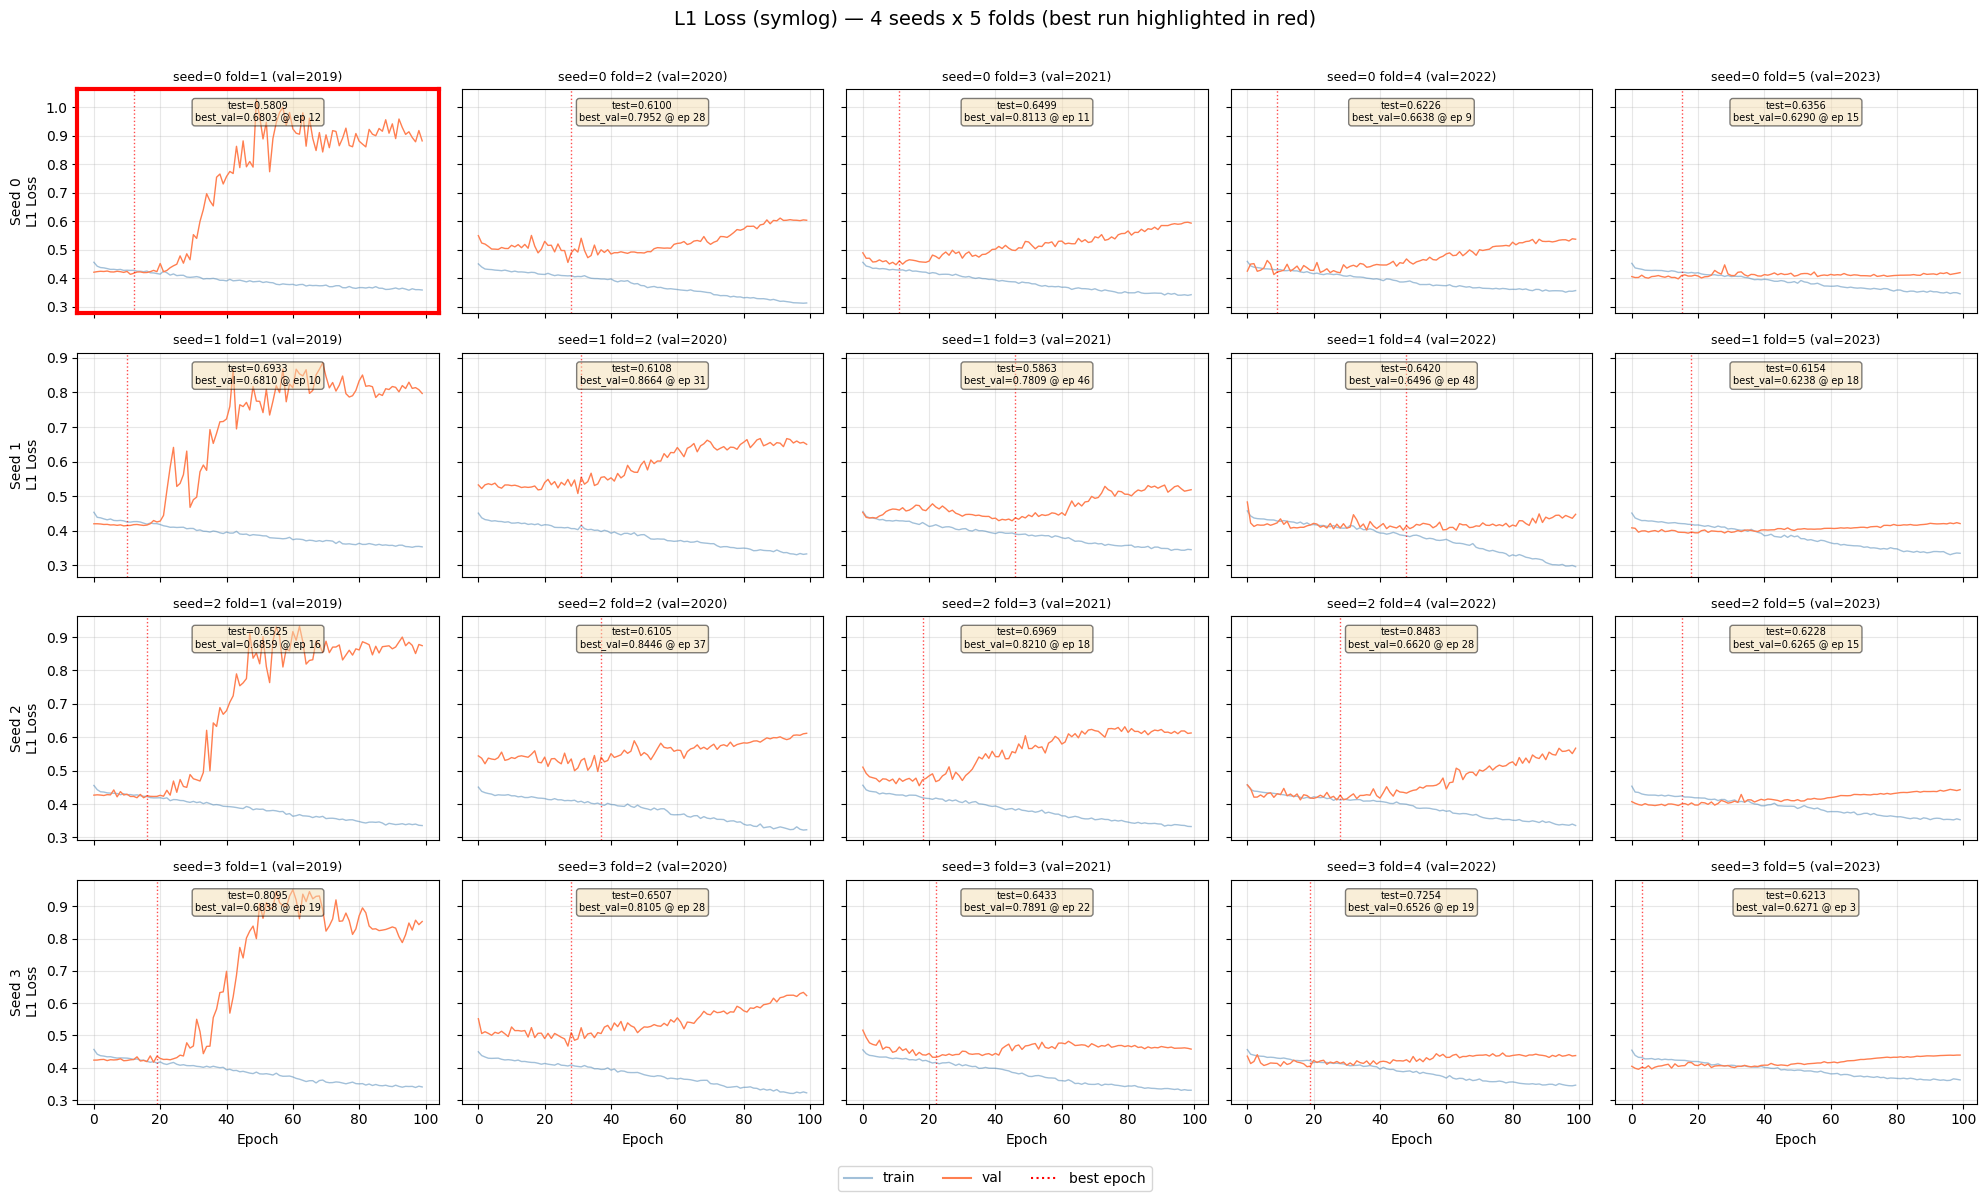

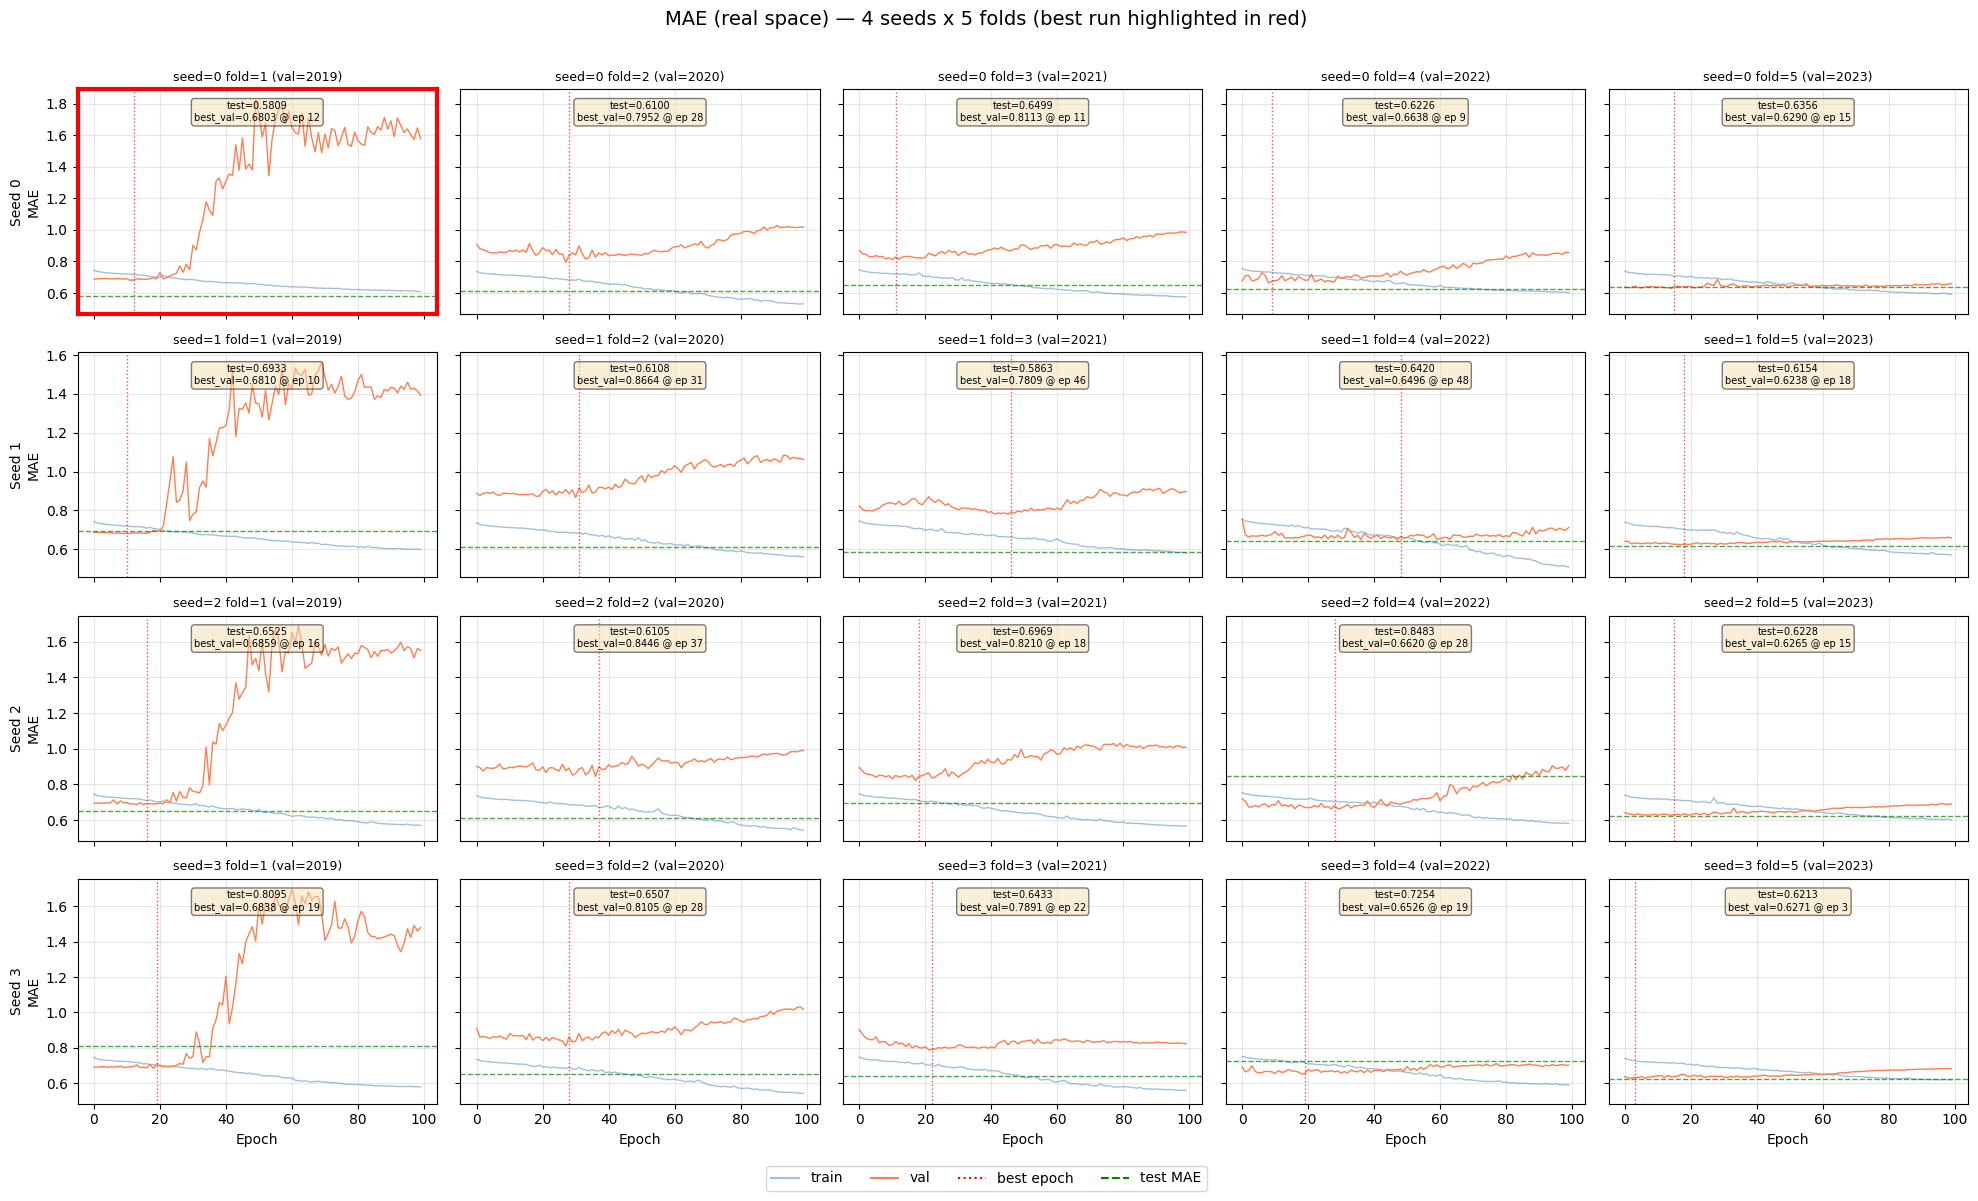

Saved multifreq_loss_grid.png and multifreq_mae_grid.png


In [ ]:
from pathlib import Path
import json as _json_diag

diag_save_dir = Path('./sweep_results_multifreq/diagnostics')
diag_save_dir.mkdir(parents=True, exist_ok=True)

def collect_predictions_multifreq_eval(model, loader):
    """Extract raw predictions, targets, and masks from a loader (symlog-inverted)."""
    model.eval()
    preds, targets, masks = [], [], []
    with torch.no_grad():
        for bd, bm, bq, by, bmask, bstatic, lengths in loader:
            bd = bd.to(DEVICE); bm = bm.to(DEVICE); bq = bq.to(DEVICE)
            bstatic = bstatic.to(DEVICE)
            logits = model(bd, bm, bq, lengths, bstatic)
            preds.append(logits.cpu().numpy())
            targets.append(by.numpy())
            masks.append(bmask.numpy())
    yp = np.vstack(preds)
    yt = np.vstack(targets)
    mask = np.vstack(masks)
    yp = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
    yp = np.sign(yp) * np.expm1(np.abs(yp))
    yt = np.sign(yt) * np.expm1(np.abs(yt))
    return yp, yt, mask

untrained_preds = {} 
for fold_idx, (train_df, val_df, val_year, fi) in enumerate(tscv_folds, start=1):
    cache = diag_save_dir / f'untrained_preds_fold{fold_idx}.json'
    if cache.exists():
        with open(cache) as f:
            d = _json_diag.load(f)
        untrained_preds[fold_idx] = (np.array(d['yp']), np.array(d['yt']), np.array(d['mask']))
        print(f"  Fold {fold_idx} (val={val_year}): untrained loaded from disk")
    else:
        set_seed(SEED)
        model_u, _, _, test_loader_u, *_ = build_loaders_multifreq(
            CONFIG, train_df, val_df, tscv_heldout_test_df
        )
        yp, yt, mask = collect_predictions_multifreq_eval(model_u, test_loader_u)
        untrained_preds[fold_idx] = (yp, yt, mask)
        with open(cache, 'w') as f:
            _json_diag.dump({'yp': yp.tolist(), 'yt': yt.tolist(), 'mask': mask.tolist()}, f)
        print(f"  Fold {fold_idx} (val={val_year}): untrained computed and cached")

N_SEEDS = 4 
N_FOLDS = N_SPLITS
val_years = [2019, 2020, 2021, 2022, 2023]

best_key = min(multifreq_runs.keys(),
               key=lambda k: multifreq_runs[k]['test_res']['Overall'])
print(f"Best (seed, fold) = {best_key}, test MAE = {multifreq_runs[best_key]['test_res']['Overall']:.4f}")

# Loss grid
fig1, axes1 = plt.subplots(N_SEEDS, N_FOLDS, figsize=(20, 12), sharex=True, sharey='row')
for (so, fi), d in multifreq_runs.items():
    ax = axes1[so, fi - 1]
    ax.plot(d['train_loss_curve'], color='steelblue', alpha=0.5, linewidth=1, label='train')
    ax.plot(d['val_loss_curve'],   color='coral',     linewidth=1, label='val')
    ax.axvline(d['best_val_epoch'], color='red', linestyle=':', linewidth=1, alpha=0.7)
    ax.set_title(f"seed={so} fold={fi} (val={val_years[fi-1]})", fontsize=9)
    ax.text(0.5, 0.95,
            f"test={d['test_res']['Overall']:.4f}\nbest_val={d['best_val_mae']:.4f} @ ep {d['best_val_epoch']}",
            transform=ax.transAxes, ha='center', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    ax.grid(True, alpha=0.3)
    if (so, fi) == best_key:
        for spine in ax.spines.values():
            spine.set_linewidth(3); spine.set_edgecolor('red')
    if so == N_SEEDS - 1:
        ax.set_xlabel('Epoch')
    if fi == 1:
        ax.set_ylabel(f'Seed {so}\nL1 Loss')

loss_handles = [
    plt.Line2D([0], [0], color='steelblue', alpha=0.5, label='train'),
    plt.Line2D([0], [0], color='coral', label='val'),
    plt.Line2D([0], [0], color='red', linestyle=':', label='best epoch'),
]
fig1.legend(handles=loss_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
            ncol=3, fontsize=10)
fig1.suptitle('L1 Loss (symlog) — 4 seeds x 5 folds (best run highlighted in red)',
             fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig(diag_save_dir / 'multifreq_loss_grid.png', dpi=120, bbox_inches='tight')
plt.show()

# MAE grid
fig2, axes2 = plt.subplots(N_SEEDS, N_FOLDS, figsize=(20, 12), sharex=True, sharey='row')
for (so, fi), d in multifreq_runs.items():
    ax = axes2[so, fi - 1]
    ax.plot(d['train_mae_curve'], color='steelblue', alpha=0.5, linewidth=1, label='train')
    ax.plot(d['val_mae_curve'],   color='coral',     linewidth=1, label='val')
    ax.axvline(d['best_val_epoch'], color='red', linestyle=':', linewidth=1, alpha=0.7)
    ax.axhline(d['test_res']['Overall'], color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f"seed={so} fold={fi} (val={val_years[fi-1]})", fontsize=9)
    ax.text(0.5, 0.95,
            f"test={d['test_res']['Overall']:.4f}\nbest_val={d['best_val_mae']:.4f} @ ep {d['best_val_epoch']}",
            transform=ax.transAxes, ha='center', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    ax.grid(True, alpha=0.3)
    if (so, fi) == best_key:
        for spine in ax.spines.values():
            spine.set_linewidth(3); spine.set_edgecolor('red')
    if so == N_SEEDS - 1:
        ax.set_xlabel('Epoch')
    if fi == 1:
        ax.set_ylabel(f'Seed {so}\nMAE')

mae_handles = [
    plt.Line2D([0], [0], color='steelblue', alpha=0.5, label='train'),
    plt.Line2D([0], [0], color='coral', label='val'),
    plt.Line2D([0], [0], color='red', linestyle=':', label='best epoch'),
    plt.Line2D([0], [0], color='green', linestyle='--', label='test MAE'),
]
fig2.legend(handles=mae_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
            ncol=4, fontsize=10)
fig2.suptitle('MAE (real space) — 4 seeds x 5 folds (best run highlighted in red)',
             fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig(diag_save_dir / 'multifreq_mae_grid.png', dpi=120, bbox_inches='tight')
plt.show()

print('Saved multifreq_loss_grid.png and multifreq_mae_grid.png')


## Prediction Distributions per-fold best seed

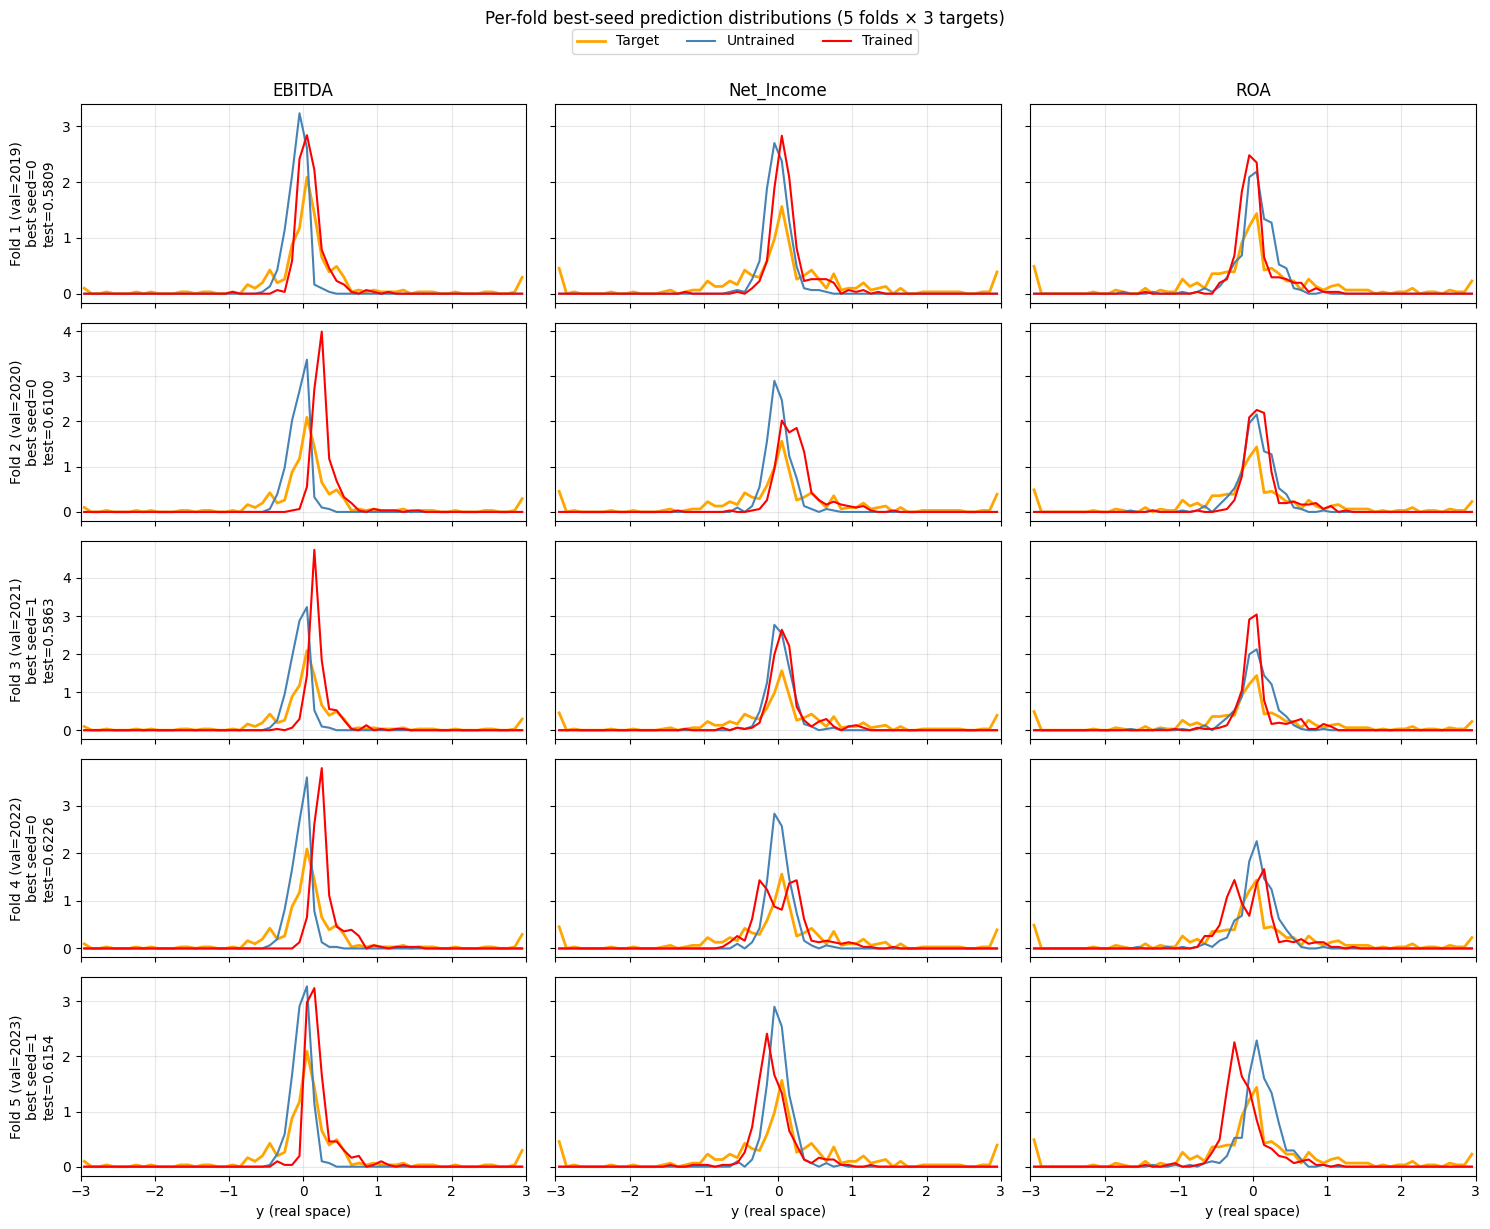

In [ ]:
BIN_EDGES = np.linspace(-WINSOR_CAP, WINSOR_CAP, 61)
BIN_CENTERS = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

# For each fold, pick the best seed (lowest test Overall MAE)
best_per_fold = {}
for fold_idx in range(1, N_SPLITS + 1):
    best_seed = 0
    best_mae = float('inf')
    for seed_offset in range(N_RUNS_TSCV):
        d = multifreq_runs[(seed_offset, fold_idx)]
        if d['test_res']['Overall'] < best_mae:
            best_mae = d['test_res']['Overall']
            best_seed = seed_offset
    best_per_fold[fold_idx] = best_seed

val_years = [2019, 2020, 2021, 2022, 2023]
fig, axes = plt.subplots(N_SPLITS, len(PREDICTION_TARGETS), figsize=(15, 12),
                         sharex=True, sharey='row')
for row, fold_idx in enumerate(range(1, N_SPLITS + 1)):
    seed_offset = best_per_fold[fold_idx]
    d = multifreq_runs[(seed_offset, fold_idx)]
    yp_t = np.array(d['test_yp_t'])
    yt = np.array(d['test_yt'])
    mask = np.array(d['test_mask'])
    yp_u, _, _ = untrained_preds[fold_idx]

    for col, t in enumerate(PREDICTION_TARGETS):
        ax = axes[row, col]
        m = mask[:, col].astype(bool)
        if m.sum() == 0:
            continue
        h_target, _ = np.histogram(yt[m, col], bins=BIN_EDGES, density=True)
        h_u, _ = np.histogram(yp_u[m, col], bins=BIN_EDGES, density=True)
        h_t, _ = np.histogram(yp_t[m, col], bins=BIN_EDGES, density=True)
        ax.plot(BIN_CENTERS, h_target, color='orange', linewidth=2, label='Target')
        ax.plot(BIN_CENTERS, h_u, color='steelblue', linewidth=1.5, label='Untrained')
        ax.plot(BIN_CENTERS, h_t, color='red', linewidth=1.5, label='Trained')
        ax.set_xlim(-WINSOR_CAP, WINSOR_CAP)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(t)
        if col == 0:
            ax.set_ylabel(f"Fold {fold_idx} (val={val_years[fold_idx-1]})\n"
                          f"best seed={seed_offset}\n"
                          f"test={d['test_res']['Overall']:.4f}")
        if row == N_SPLITS - 1:
            ax.set_xlabel("y (real space)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Per-fold best-seed prediction distributions (5 folds × 3 targets)", y=1.02)
plt.tight_layout()
plt.savefig(diag_save_dir / 'multifreq_distribs.png', dpi=120, bbox_inches='tight')
plt.show()


## Target vs Predicted Scatter

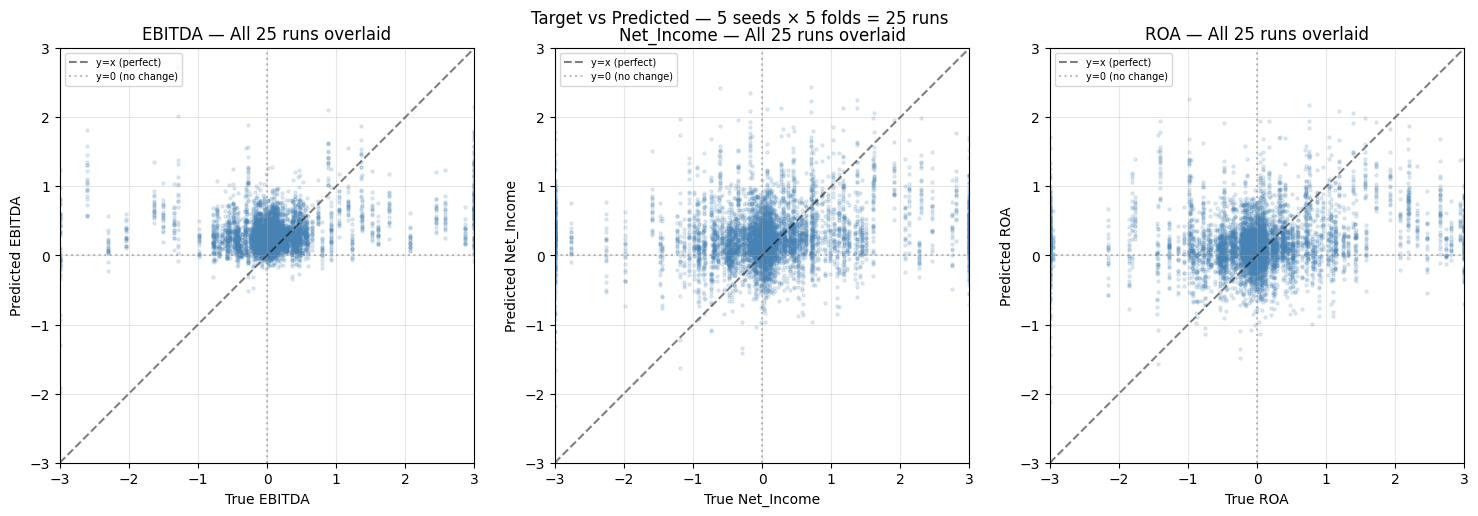

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for col, t in enumerate(PREDICTION_TARGETS):
    ax = axes[col]
    for seed_offset in range(N_RUNS_TSCV):
        for fold_idx in range(1, N_SPLITS + 1):
            d = multifreq_runs[(seed_offset, fold_idx)]
            yp_t = np.array(d['test_yp_t'])
            yt = np.array(d['test_yt'])
            mask = np.array(d['test_mask'])
            m = mask[:, col].astype(bool)
            ax.scatter(yt[m, col], yp_t[m, col], s=5, alpha=0.15, color='steelblue')
    lim = [-WINSOR_CAP, WINSOR_CAP]
    ax.plot(lim, lim, 'k--', alpha=0.5, label='y=x (perfect)')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5, label='y=0 (no change)')
    ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'True {t}'); ax.set_ylabel(f'Predicted {t}')
    ax.set_title(f'{t} — All 25 runs overlaid')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper left')
    ax.set_aspect('equal')
plt.suptitle("Target vs Predicted — 5 seeds × 5 folds = 25 runs")
plt.tight_layout()
plt.savefig(diag_save_dir / 'multifreq_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


## Percentage-Error Diagnostics (MAPE / SMAPE)

In [ ]:

import os
pct_save_dir = Path('./sweep_results_multifreq/diagnostics')
pct_save_dir.mkdir(parents=True, exist_ok=True)

def compute_pct_metrics(yp, yt, mask, eps=0.01):
    """Compute MAE, MAPE, SMAPE per target.
    MAPE: only where |true| > eps (avoid division by zero).
    SMAPE: bounded 0-200%, well-defined for true=0.
    """
    res = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            res[t] = {'MAE': np.nan, 'MAPE': np.nan, 'SMAPE': np.nan}
            continue
        # MAE (existing metric, in ratio space)
        res[t] = {'MAE': float(np.abs(yp[m, i] - yt[m, i]).mean())}
        # MAPE: only where |true| > eps
        big = m & (np.abs(yt[:, i]) > eps)
        if big.sum() > 0:
            res[t]['MAPE'] = float((np.abs(yp[big, i] - yt[big, i]) / np.abs(yt[big, i])).mean() * 100)
        else:
            res[t]['MAPE'] = np.nan
        # SMAPE: bounded 0-200%
        denom = np.abs(yp[m, i]) + np.abs(yt[m, i]) + 1e-8
        res[t]['SMAPE'] = float((2 * np.abs(yp[m, i] - yt[m, i]) / denom).mean() * 100)
    return res

# Compute MAPE/SMAPE for all 20 (seed, fold) runs of MultiFreq
multifreq_pct = {}
for (so, fi), d in multifreq_runs.items():
    yp = np.array(d['test_yp_t'])
    yt = np.array(d['test_yt'])
    mask = np.array(d['test_mask'])
    multifreq_pct[(so, fi)] = compute_pct_metrics(yp, yt, mask)

# Aggregate: per-target mean +/- std across (seed, fold)
rows = []
for (so, fi), m_dict in multifreq_pct.items():
    for t in PREDICTION_TARGETS:
        for metric_name in ['MAE', 'MAPE', 'SMAPE']:
            rows.append({
                'seed_offset': so, 'fold_idx': fi, 'target': t,
                'metric': metric_name, 'value': m_dict[t][metric_name]
            })
df_pct = pd.DataFrame(rows)

print("MultiFreqLSTM - MAE, MAPE, SMAPE across 20 (seed, fold) runs")
print("(MAPE is % error; SMAPE is bounded 0-200%)\n")
summary_pct = df_pct.groupby(['target', 'metric'])['value'].agg(['mean', 'std']).round(2)
display(summary_pct)

# Best (seed, fold)
best_pct_mae = min(multifreq_runs.keys(),
                    key=lambda k: multifreq_runs[k]['test_res']['Overall'])
print(f"\nBest run = {best_pct_mae}, test MAE = {multifreq_runs[best_pct_mae]['test_res']['Overall']:.4f}")
print("Per-target MAE / MAPE / SMAPE for the best run:")
for t in PREDICTION_TARGETS:
    m = multifreq_pct[best_pct_mae][t]
    print(f"  {t:12s}  MAE={m['MAE']:.4f}  MAPE={m['MAPE']:6.2f}%  SMAPE={m['SMAPE']:6.2f}%")

# Histogram of per-sample % errors per target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, t in enumerate(PREDICTION_TARGETS):
    ax = axes[col]
    # Concatenate % errors across all (seed, fold) runs
    all_errs_list = []
    for k in multifreq_runs.keys():
        yp = np.array(multifreq_runs[k]['test_yp_t'])
        yt = np.array(multifreq_runs[k]['test_yt'])
        mask = np.array(multifreq_runs[k]['test_mask'])
        ti = PREDICTION_TARGETS.index(t)
        m = mask[:, ti] & (np.abs(yt[:, ti]) > 0.01)
        if m.sum() > 0:
            pct_err = np.abs(yp[m, ti] - yt[m, ti]) / np.abs(yt[m, ti]) * 100
            all_errs_list.append(pct_err)
    if all_errs_list:
        all_errs = np.concatenate(all_errs_list)
        all_errs_capped = np.clip(all_errs, 0, 300)
        ax.hist(all_errs_capped, bins=50, color='steelblue', alpha=0.7,
                edgecolor='black', linewidth=0.5)
        ax.axvline(np.median(all_errs), color='coral', linestyle='--', linewidth=2,
                    label=f'median = {np.median(all_errs):.1f}%')
        ax.set_xlabel('|pred - true| / |true| (%)')
        ax.set_ylabel('count')
        ax.set_title(f'{t} (n={len(all_errs)})')
        ax.set_xlim(0, 300)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
fig.suptitle('Per-sample percentage error distribution (capped at 300%, all 20 runs pooled)')
plt.tight_layout()
plt.savefig(pct_save_dir / 'multifreq_pct_error_hist.png', dpi=120, bbox_inches='tight')
plt.show()

# Target vs % error scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, t in enumerate(PREDICTION_TARGETS):
    ax = axes[col]
    for (so, fi), d in multifreq_runs.items():
        yp = np.array(d['test_yp_t'])
        yt = np.array(d['test_yt'])
        mask = np.array(d['test_mask'])
        ti = PREDICTION_TARGETS.index(t)
        m = mask[:, ti] & (np.abs(yt[:, ti]) > 0.01)
        if m.sum() > 0:
            pct_err = np.abs(yp[m, ti] - yt[m, ti]) / np.abs(yt[m, ti]) * 100
            pct_err_capped = np.clip(pct_err, 0, 500)
            ax.scatter(yt[m, ti], pct_err_capped, s=4, alpha=0.15, color='steelblue')
    ax.axhline(100, color='red', linestyle=':', alpha=0.5, label='100% error line')
    ax.set_xlabel(f'True {t}')
    ax.set_ylabel('% error (capped at 500%)')
    ax.set_title(f'{t}')
    ax.set_xlim(-3, 3)
    ax.set_ylim(0, 500)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Per-sample percentage error vs true target value (all 20 runs overlaid)')
plt.tight_layout()
plt.savefig(pct_save_dir / 'multifreq_pct_error_scatter.png', dpi=120, bbox_inches='tight')
plt.show()


## TSCV Results Summary

In [ ]:
rows = []
for (so, fi), d in multifreq_runs.items():
    for t in PREDICTION_TARGETS + ['Overall']:
        rows.append({
            'seed': d['seed'], 'fold': fi, 'val_year': d['val_year'],
            'target': t,
            'test_mae': d['test_res'].get(t),
            'test_2024_mae': d['test_res_2024'].get(t),
            'test_2025_mae': d['test_res_2025'].get(t),
            'best_val_mae': d['best_val_mae'],
            'best_val_epoch': d['best_val_epoch'],
        })
df_mf_per_run = pd.DataFrame(rows)

summary_rows = []
for t in PREDICTION_TARGETS + ['Overall']:
    sub = df_mf_per_run[df_mf_per_run['target'] == t]
    val_per_run = pd.DataFrame([
        {'seed_offset': so, 'fold_idx': fi,
         'best_val_mae': multifreq_runs[(so, fi)]['best_val_mae']}
        for so in range(N_RUNS_TSCV) for fi in range(1, N_SPLITS + 1)
    ])
    summary_rows.append({
        'target': t,
        'avg_val_mae': float(val_per_run['best_val_mae'].mean()) if t == 'Overall' else None,
        'std_val_mae': float(val_per_run['best_val_mae'].std()) if t == 'Overall' else None,
        'test_mae_mean': float(sub['test_mae'].mean()),
        'test_mae_std':  float(sub['test_mae'].std()),
        'test_2024_mean': float(sub['test_2024_mae'].mean()),
        'test_2024_std':  float(sub['test_2024_mae'].std()),
        'test_2025_mean': float(sub['test_2025_mae'].mean()),
        'test_2025_std':  float(sub['test_2025_mae'].std()),
    })
df_mf = pd.DataFrame(summary_rows)
display(df_mf.round(4))

print("\n=== Verdict (MultiFreq TSCV) ===")
for metric_name, col in [('Avg val MAE', 'avg_val_mae'),
                          ('Test MAE (all)', 'test_mae_mean'),
                          ('Test MAE (2024)', 'test_2024_mean'),
                          ('Test MAE (2025)', 'test_2025_mean')]:
    if df_mf[df_mf['target'] == 'Overall'][col].notna().any():
        v = float(df_mf[df_mf['target'] == 'Overall'][col].iloc[0])
        print(f"  {metric_name:25s}: {v:.4f}")

,target,avg_val_mae,std_val_mae,test_mae_mean,test_mae_std,test_2024_mean,test_2024_std,test_2025_mean,test_2025_std
0,EBITDA,NaN,NaN,0.4902,0.0866,0.5223,0.0873,0.4567,0.0896
1,Net_Income,NaN,NaN,0.7567,0.0810,0.7310,0.0894,0.7837,0.1054
2,ROA,NaN,NaN,0.7220,0.0722,0.7137,0.0807,0.7306,0.0965
3,Overall,0.7192,0.0841,0.6564,0.0692,0.6558,0.0808,0.6570,0.0768



=== Verdict (MultiFreq TSCV) ===
  Avg val MAE              : 0.7192
  Test MAE (all)           : 0.6564
  Test MAE (2024)          : 0.6558
  Test MAE (2025)          : 0.6570
